## 데이터 타입 변환 & 결측치 처리 기초

In [112]:
import pandas as pd

# 예시 데이터 프레임 생성
data = pd.DataFrame({
    'A':['1','2','3'],
    'B':['4','5','6'],
    'C':['7','8','9']
})

data

,A,B,C
0,1,4,7
1,2,5,8
2,3,6,9


In [113]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       3 non-null      str  
 1   B       3 non-null      str  
 2   C       3 non-null      str  
dtypes: str(3)
memory usage: 204.0 bytes


### apply(pd.to_numeric)
- 선택한 여러 열에 한번에 숫자 변환 함수를 적용한다.

In [114]:
# 데이터타입을 int로 변경
data[['A', 'B', 'C']] = data[['A', 'B', 'C']].apply(pd.to_numeric)

In [115]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       3 non-null      int64
 1   B       3 non-null      int64
 2   C       3 non-null      int64
dtypes: int64(3)
memory usage: 204.0 bytes


In [116]:
pd.__version__

'3.0.3'

## dropna()
- 결측값이 있는 행 제거
- 가장 간단하지만 데이터가 많이 삭제될 수 있어 신중하게 사용해야 한다.
- 결측치 비율이 매우 낮을 때만 사용하는걸 권장
- 기본값은 행 기준(axis=0)
- sxis --> 열(컬럼) 기준

In [117]:
data = pd.DataFrame({
    'A':['1','2','3', None],
    'B':['4',None, '5','6'],
    'C':[None, '7','8','9']
})

data

,A,B,C
0,1,4,NaN
1,2,NaN,7
2,3,5,8
3,NaN,6,9


In [118]:
data.dropna() # 데이터가 4줄 중 3줄이 날라감

,A,B,C
2,3,5,8


In [119]:
data

,A,B,C
0,1,4,NaN
1,2,NaN,7
2,3,5,8
3,NaN,6,9


In [120]:
data_dropna = data.dropna()

data_dropna

,A,B,C
2,3,5,8


In [121]:
data

,A,B,C
0,1,4,NaN
1,2,NaN,7
2,3,5,8
3,NaN,6,9


In [122]:
data_dropna_col = data.dropna(axis=1)

data_dropna_col

""
0
1
2
3


## fillna(다른값)
- 결측치를 다른 값으로 채우기

## 결측값을 0으로 채우기
- 행이 삭제되지 않아 데이터 손실은 없지만, 0이라는 값의 실체 의미가 작용할 때는 혼동될 수 있다.

In [123]:
data

,A,B,C
0,1,4,NaN
1,2,NaN,7
2,3,5,8
3,NaN,6,9


In [124]:
data.fillna(0)

,A,B,C
0,1,4,0
1,2,0,7
2,3,5,8
3,0,6,9


In [125]:
data.fillna0 = data.fillna(0)

data.fillna0

C:\Users\Administrator\AppData\Local\Temp\ipykernel_920\907154935.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  data.fillna0 = data.fillna(0)


,A,B,C
0,1,4,0
1,2,0,7
2,3,5,8
3,0,6,9


## 결측값을 평균으로 채우기 - fillna(mean())
- main(): 평균
- 숫자형 데이터(나이, 온도, 점수 등)에서 가장 널리 쓰이는 결측치 처리 방식
- 극단적인 이상치가 있으면 평균이 왜곡될 수 있으니, 이상치 제거 후 평균을 채우는 순서가 안전하다.

In [126]:
data

,A,B,C
0,1,4,NaN
1,2,NaN,7
2,3,5,8
3,NaN,6,9


In [127]:
data['A']

0      1
1      2
2      3
3    NaN
Name: A, dtype: str

In [128]:
data_numeric = data.apply(pd.to_numeric) # 숫자형으로 변환
data_numeric # 새로운 데이터 프래임

,A,B,C
0,1.0,4.0,NaN
1,2.0,NaN,7.0
2,3.0,5.0,8.0
3,NaN,6.0,9.0


In [129]:
data_numeric.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       3 non-null      float64
 1   B       3 non-null      float64
 2   C       3 non-null      float64
dtypes: float64(3)
memory usage: 228.0 bytes


In [130]:
data_numeric.mean()

A    2.0
B    5.0
C    8.0
dtype: float64

In [131]:
data_numeric.fillna(data_numeric.mean())

,A,B,C
0,1.0,4.0,8.0
1,2.0,5.0,7.0
2,3.0,5.0,8.0
3,2.0,6.0,9.0


In [132]:
avg = data_numeric.mean()

avg

A    2.0
B    5.0
C    8.0
dtype: float64

In [133]:
data_numeric = data_numeric.fillna(avg) # 덮어쓰기

In [134]:
data_numeric

,A,B,C
0,1.0,4.0,8.0
1,2.0,5.0,7.0
2,3.0,5.0,8.0
3,2.0,6.0,9.0


## 결측값을 최빈값으로 채우기

## 최빈값 : mode()
- 해당 열에서 가장 자주 나온 값들을 리스트 형태로 변환
- 최빈값이 여러개 여도 첫번째 값 불러오기 --> [0] (인덱싱 해야 됨)

In [135]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       3 non-null      str  
 1   B       3 non-null      str  
 2   C       3 non-null      str  
dtypes: str(3)
memory usage: 228.0 bytes


In [136]:
mode_a = data['A'].mode()

mode_a

0    1
1    2
2    3
Name: A, dtype: str

In [137]:
type(mode_a)

pandas.Series

In [138]:
mode_a[0]

'1'

In [139]:
mode_b = data['B'].mode()[0]

mode_b

'4'

In [140]:
mode_c = data['C'].mode()[0]

mode_c

'7'

In [141]:
data.fillna(mode_b)

,A,B,C
0,1,4,4
1,2,4,7
2,3,5,8
3,4,6,9


In [142]:
# 데이터 프레임의 열마다 같은 코드를 반복 적용시킬때
data.apply(lambda x: x.fillna(x.mode()[0])) 

,A,B,C
0,1,4,7
1,2,4,7
2,3,5,8
3,1,6,9


In [143]:
# lambda 매개변수: 함수 몸통(리턴값)
f = lambda x: x + 1 #매개변수 x에 + 1을 한다.

f(2) # 매개변수 x자리에 2가 들어갔다. -> +1을 했다 -> 결과 3이 나왔다.

3

In [144]:
result = f(5)
result

6

## 열마다 다른 값으로 결측치 대체(딕셔너리 활용)
- 열마다 성격이 다를때 사용
- 성별은 최빈값, 지역은 '기타'

In [145]:
data2 = pd.DataFrame({
    '성별':['남', '남', '여', '남', None, '여'],
    '지역':['대구', '서울', '서울', None, '대구', None],
    '나이':[20, 30, None, None, 38, 22]
})

data2

,성별,지역,나이
0,남,대구,20.0
1,남,서울,30.0
2,여,서울,NaN
3,남,NaN,NaN
4,NaN,대구,38.0
5,여,NaN,22.0


In [146]:
data2_fillna = data2.fillna({'성별':'남', '지역':'기타', '나이':20})

data2_fillna

,성별,지역,나이
0,남,대구,20.0
1,남,서울,30.0
2,여,서울,20.0
3,남,기타,20.0
4,남,대구,38.0
5,여,기타,22.0


In [147]:
data2_fillna2 = data2.fillna({'성별': data2['성별'].mode()[0], # 최빈값
                              '지역':'기타',                   # 값을 직접 대입
                              '나이': data2['나이'].mean()})   # 평균
data2_fillna2

,성별,지역,나이
0,남,대구,20.0
1,남,서울,30.0
2,여,서울,27.5
3,남,기타,27.5
4,남,대구,38.0
5,여,기타,22.0


In [148]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 예시 데이터 프레임 생성
# np.random.randn(8, 3): 평균0, 표준편차 1인 정규분포 난수 8행 3열 생성
df = pd. DataFrame(np.random.randn(8,3), columns=['C1', 'C2', 'C3']) # columns로 컬럼 이름 넣기

df

,C1,C2,C3
0,0.104717,2.173977,1.796712
1,1.034863,1.269452,1.342819
2,0.714402,-0.144847,-0.677306
3,-1.563738,-1.481275,-1.395164
4,-0.779655,0.653372,-0.884371
5,0.518042,0.207913,1.933701
6,-0.060800,-0.587929,-1.640607
7,0.035222,-0.458251,-0.141485


In [149]:
# 극단 적인 값(이상치)를 강제로 넣는다.
# 데이터 프레임.loc[행 이름, 열 이름]
df.loc[1,'C1'] = 11

df

,C1,C2,C3
0,0.104717,2.173977,1.796712
1,11.000000,1.269452,1.342819
2,0.714402,-0.144847,-0.677306
3,-1.563738,-1.481275,-1.395164
4,-0.779655,0.653372,-0.884371
5,0.518042,0.207913,1.933701
6,-0.060800,-0.587929,-1.640607
7,0.035222,-0.458251,-0.141485


In [150]:
df.loc[3, 'C3'] = -10

df

,C1,C2,C3
0,0.104717,2.173977,1.796712
1,11.000000,1.269452,1.342819
2,0.714402,-0.144847,-0.677306
3,-1.563738,-1.481275,-10.000000
4,-0.779655,0.653372,-0.884371
5,0.518042,0.207913,1.933701
6,-0.060800,-0.587929,-1.640607
7,0.035222,-0.458251,-0.141485


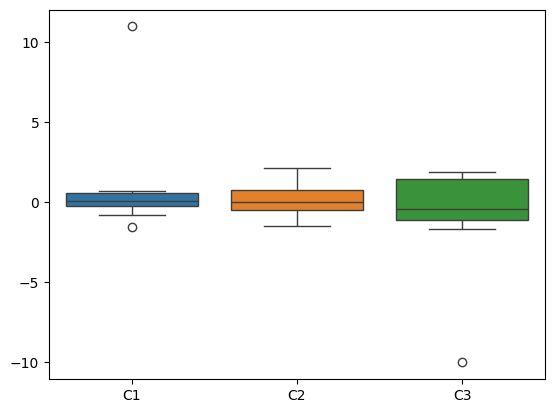

In [151]:
sns.boxplot(data=df)
plt.show()

## 데이터 프레임.corr()
- 열들 사이의 상관계수(-1 ~  1)를 계산한 표
- 1에 가까우면 강한 양의 상관관계
- -1에 가까우면 강한 음의 상관관계
- heatmap 그래프로 상관관계를 표현할 수 있다.
    - annot = True : 히트맵의 각 칸에 실제 상관계수 숫자를 함께 표시해준다.

In [158]:
df.corr()

,C1,C2,C3
C1,1.000000,0.433876,0.389978
C2,0.433876,1.000000,0.743136
C3,0.389978,0.743136,1.000000


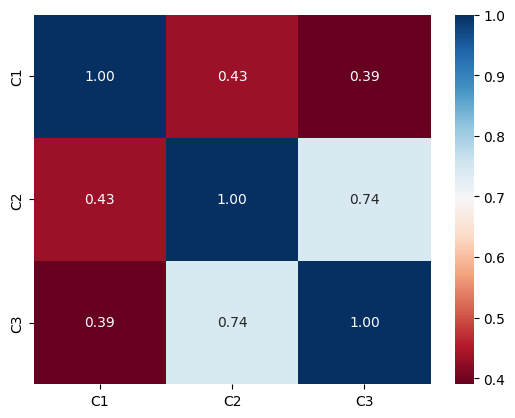

In [157]:
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdBu')
plt.show()